In [59]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [60]:
from Bio import SeqIO
from BCBio import GFF

seq = SeqIO.parse("../../data/GCF_008369605.1/GCF_008369605.1_ASM836960v1_genomic.fna", "fasta")
annotations = GFF.parse(open("../../data/GCF_008369605.1/genomic.gff"))
chromo1, chromo2, plasmid = [*seq]

In [61]:
# Search for oriC or DnaA in the annotations
for rec in annotations:
    for feature in rec.features:
        # Buscar oriC o DnaA directamente
        if any(keyword in str(feature.qualifiers).lower()
               for keyword in ["oric", "dnaa", "replication"]):
            print(rec.id)
            print(feature.type)
            print(feature.location)
            print(feature.qualifiers)
            print("---")

NZ_CP043554.1
gene
[2902457:2903861](+)
{'ID': ['gene-F0316_RS13590'], 'Dbxref': ['GeneID:69721169'], 'Name': ['dnaA'], 'gbkey': ['Gene'], 'gene': ['dnaA'], 'gene_biotype': ['protein_coding'], 'locus_tag': ['F0316_RS13590'], 'old_locus_tag': ['F0316_13590'], 'source': ['RefSeq']}
---


In [62]:
dnaA_start = 2902457
dnaA_end = 2903861

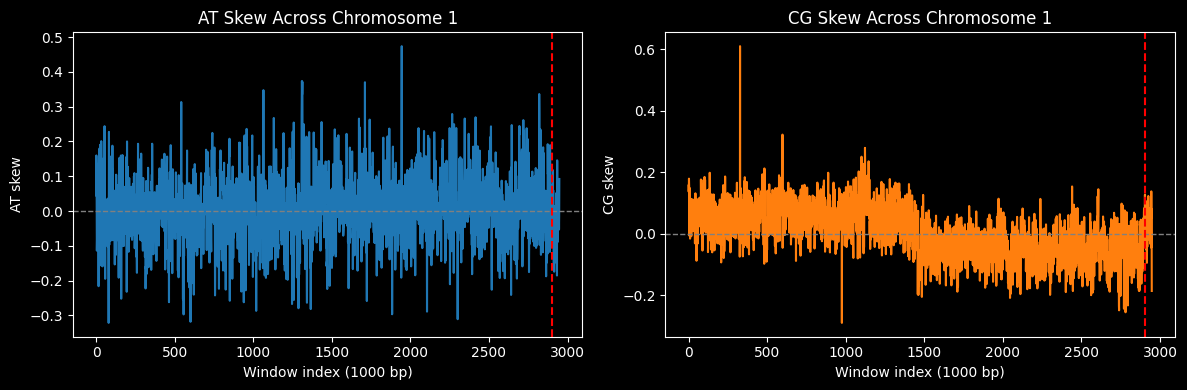

In [63]:
from utils.sequence_analysis import SkewPlots
oric_mid = (dnaA_start + dnaA_end) / 2
SkewPlots.plot_window_skew(chromo1, window_size=1000, dnaA_mid=oric_mid)

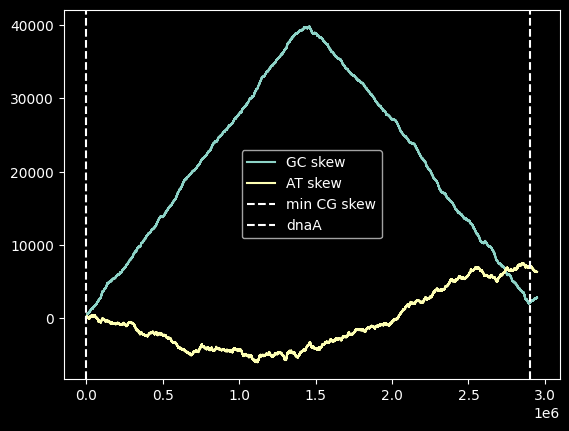

94


In [64]:
min_cg_skew = SkewPlots.plot_diagram_skew(chromo1.seq, dnaA_mid=oric_mid)
print(min_cg_skew)

In [76]:
# Now rotate the DNA so the min skew represents oriC
rotated_sequence = chromo1.seq
k = len(rotated_sequence) // 3
rotated_sequence = rotated_sequence[k:] + rotated_sequence[:k]
def wrap(value, min_val, max_val):
    rang = max_val - min_val
    return min_val + (value - min_val) % rang

rotated_oric_mid = wrap(oric_mid - k, 0, len(rotated_sequence))

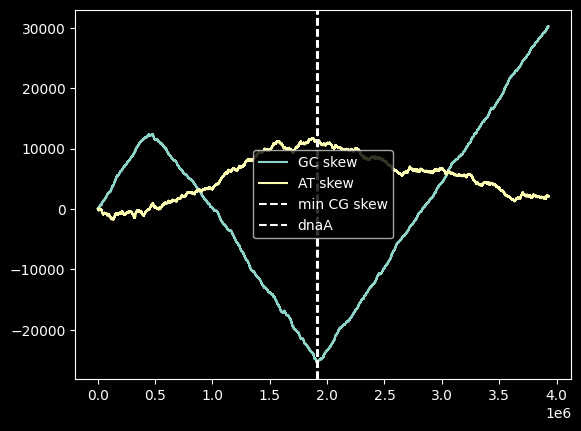

1911122


In [81]:
min_cg_skew = SkewPlots.plot_diagram_skew(rotated_sequence, dnaA_mid=rotated_oric_mid)
print(min_cg_skew)

In [67]:
window_size = 10000
left_index = min_cg_skew - (window_size // 2)
right_index = min_cg_skew + (window_size // 2)
if left_index < 0:
    chromo_window = chromo1.seq[left_index:] + chromo1.seq[:right_index]
else:
    chromo_window = chromo1.seq[left_index:right_index]
print(left_index, right_index)

1906122 1916122


In [68]:
counts = {}
k = 9
max_hamming = 1

differences = lambda s1, s2: sum(1 for a, b in zip(s1, s2) if a != b)

# Count the "base" matches
for i in range(len(chromo_window) - k + 1):
    kmer = chromo_window[i:i + k]
    reverse_complement = kmer.reverse_complement()
    canonical = min(kmer, reverse_complement)

    similar = False
    for kmer_seen in counts.keys():
        if differences(canonical, kmer_seen) <= max_hamming:
            counts[kmer_seen] += 1
            similar = True
            break
    if not similar:
        counts[canonical] = 1

In [74]:
# Now searh for the representation of DnaA
from Bio.Seq import Seq

dnaA = Seq("TTATCCACA")
reverse_complement = dnaA.reverse_complement()
canonical = min(dnaA, reverse_complement)
if canonical in counts:
    print(f"Found a match! {counts[canonical]} times")

for kmer_seen in counts.keys():
    if differences(canonical, kmer_seen) <= max_hamming:
        print(f"Found a match! {counts[kmer_seen]} times: {kmer_seen}")

Found a match! 5 times: TGTGGCTAA
Found a match! 1 times: TGTGTATAA


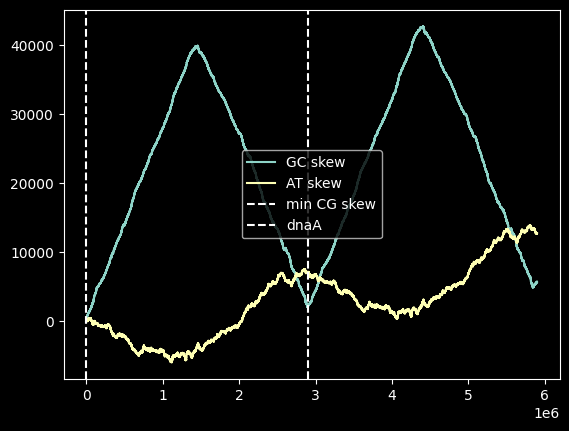

In [80]:
# Now chart the original chromosome twice to check for rotation invariability
min_cg_skew = SkewPlots.plot_diagram_skew(chromo1.seq * 2, dnaA_mid=oric_mid)